# 1.Iniciativas legislativas 2009-2024 (LEY muerte súbita)

In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
import datetime
print(datetime.datetime.now().strftime("%Y%m%d%H%M"))

202505101314


In [3]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

## Identificar proyectos de ley con la palabra muerte súbita en su título 

In [4]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

In [5]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


In [6]:
proyecto_SUBITA_df = basetexto_df[basetexto_df['Título'].str.contains(pat = 'MUERTE SUBITA')]
proyecto_SUBITA_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 3168 to 33533
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   Proyecto.ID                         10 non-null     category
 1   Título                              10 non-null     category
 2   Título procesado                    10 non-null     object  
 3   Título normalizado                  10 non-null     object  
 4   Cant_token                          10 non-null     int64   
 5   Cant_token_normalizado              10 non-null     int64   
 6   Proyecto_girado_a_comisiones_SALUD  10 non-null     float64 
 7   Proyecto_SALUD                      10 non-null     float64 
 8   Resultado                           10 non-null     category
 9   Max_Orden                           10 non-null     int64   
 10  Tiene_antecedente_por_titulo_proy   10 non-null     bool    
 11  Periodo                          

In [7]:
proyecto_SUBITA_df[['Proyecto.ID','Título','Título normalizado']].head(6)

,Proyecto.ID,Título,Título normalizado
3168,HCDN266842,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,proteccion embarazo recien nacido ley muerte subitar sistema prevencion integral instruccion basico rcp nacional progenitor nino recien nacido situacion riesgo
5898,HCDN255602,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar
8633,HCDN243571,"MUERTE SUBITA. SISTEMA DE PREVENCION INTEGRAL - LEY 27159 -. MODIFICACIONES SOBRE LA COLOCACION DE DISPOSITIVOS DEA EN ESTABLECIMIENTOS EDUCATIVOS PUBLICOS Y PRIVADOS, ESTABLECIMIENTOS DEPORTIVOS, GIMNASIOS, CLUBES Y SERVICIOS DE ALOJAMIENTO CON SECTORES DEPORTIVOS .",muerte subitar sistema prevencion integral colocacion dispositivo dea establecimiento educativo publico privado establecimiento deportivo gimnasio club servicio alojamiento sector deportivo
10195,HCDN238109,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar
14084,HCDN215087,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar
19669,HCDN185534,PROGRAMA DE PREVENCION DE MUERTE SUBITA EN NIÑOS EN EDAD ESCOLAR Y ADOLESCENTES. REGIMEN.,programa prevencion muerte subitar nino edad escolar adolescente regimen


In [8]:
proyecto_SUBITA_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,10,10,HCDN215087,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,10,9,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,10,8,programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita regimen capacitacion en reanimacion cardiopulmonar,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,10,7,programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,10.0,NaN,NaN,NaN,23.7,9.080504,14.0,18.5,22.5,24.0,43.0
Cant_token_normalizado,10.0,NaN,NaN,NaN,13.8,4.104198,9.0,10.0,14.0,15.0,20.0
Proyecto_girado_a_comisiones_SALUD,10.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Proyecto_SALUD,10.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Resultado,10,1,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,10.0,NaN,NaN,NaN,2.8,0.918937,2.0,2.0,2.5,3.75,4.0


In [9]:
Temp = pd.pivot_table(basetexto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Año'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp

,Año,Cant_token,Cant_token_normalizado
0,2009,19.0,10.0
1,2010,18.0,9.0
2,2011,19.0,10.0
3,2012,17.0,8.0
4,2013,17.0,9.0
5,2014,18.0,9.0
6,2015,19.0,10.0
7,2016,16.0,8.0
8,2017,18.0,9.0
9,2018,18.0,9.0


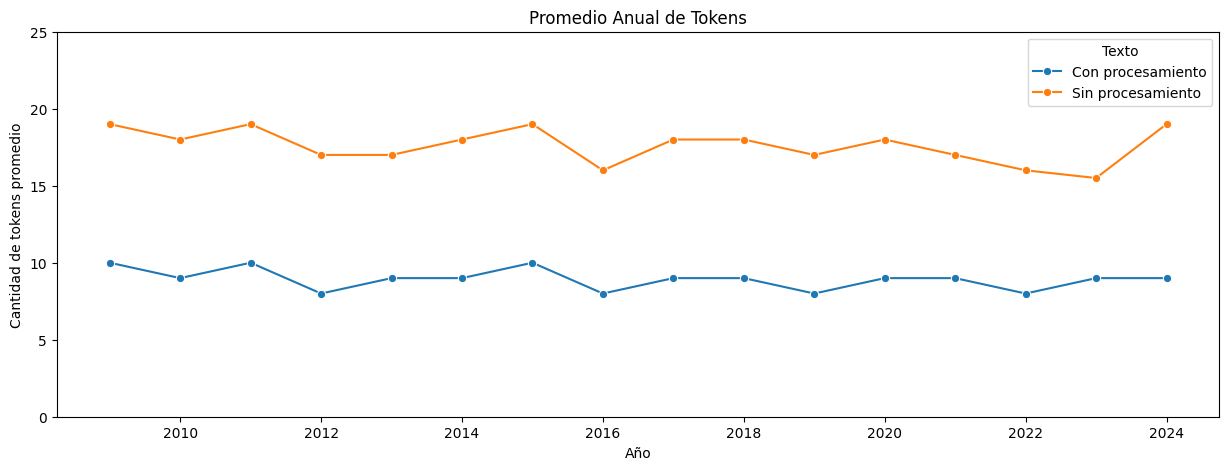

In [10]:
import matplotlib.ticker as ticker
sns.color_palette("pastel")
Temp1 = pd.melt(Temp, id_vars=['Año'], value_vars=['Cant_token_normalizado', 'Cant_token'])
Temp1.columns = ['Año','Texto','Cantidad de tokens promedio']
Temp1["Texto"] = Temp1["Texto"].map({'Cant_token': 'Sin procesamiento', 'Cant_token_normalizado': 'Con procesamiento'})

f, ax = plt.subplots(1, 1, figsize=(15, 5), sharey = True)
sns.lineplot(x='Año', y='Cantidad de tokens promedio', hue='Texto', data = Temp1, estimator='sum', errorbar= None , linestyle='-', ax = ax, marker="o")
legend_handles, _= ax.get_legend_handles_labels()

ax.set_title('Promedio Anual de Tokens')
plt.ylim(0, 25)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
#plt.savefig(BASE_DIR+"imagenes/evolucion_IL_a_tokennos.png")
plt.show()

## Identificar textos de proyecto de muerte súbita raspados en sitio web 

Es importante conocer el expediente de diputados. Atributos clave para integrar textos ante las fuentes disponibles: 'metadata.expediente diputados' o 'links a textos a descargar.expediente diputados'

In [11]:
 with open(RESULTADOS_DIR+'/muerte_subita/pms_texto_df_POC'+'.pkl', "rb") as f:
        pms_texto_df = pickle.load(f)
pms_texto_df.head(2)

metadata.expediente diputados  Cant_pag  \
0                   0018-d-2022       6.0   
1                   0387-d-2024       9.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [12]:
pms_texto_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 94841
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   metadata.expediente diputados  32 non-null     object 
 1   Cant_pag                       11 non-null     float64
 2   texto_proyecto                 31 non-null     object 
dtypes: float64(1), object(2)
memory usage: 1.0+ KB


In [13]:
 with open(RESULTADOS_DIR+'/muerte_subita/proyectos_72_integrado_20240708'+'.pkl', "rb") as f:
        pms_df = pickle.load(f)
pms_df.head(2)

,tipo de proyecto,denominacion,metadata.iniciado en,metadata.expediente diputados,metadata.publicado en,metadata.fecha,detalles.firmantes,detalles.giro a comisiones en diputados,links a textos a descargar.iniciado en,links a textos a descargar.expediente diputados,...,proyecto_id,titulo,publicacion_fecha,publicacion_id,camara_origen,exp_diputados,exp_senadores,tipo,_merge,indice
813,proyecto de ley,programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita. regimen. capacitacion en reanimacion cardiopulmonar.,diputados,0018-d-2022,trámite parlamentario n° 1,02/03/2022,"[{'firmante': 'camaño, graciela', 'distrito': 'buenos aires', 'bloque': 'identidad bonaerense'}]","[{'comisión': 'accion social y salud publica'}, {'comisión': 'familias, niñez y juventudes'}, {'comisión': 'educacion'}, {'comisión': 'presupuesto y hacienda'}]",diputados,0018-d-2022,...,hcdn255602,programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita. regimen. capacitacion en reanimacion cardiopulmonar.,2022-03-02,hcdn140tp001,diputados,0018-d-2022,nan,ley,both,813
3251,proyecto de ley,"instituyendo el mes de octubre de cada año como ""mes nacional de concientizacion sobre el sindrome de muerte subita del lactante, los factores de riesgo y sus medidas preventivas""",senado,0091-s-2016,diario de asuntos entrados n° 127,12/08/2015,"[{'firmante': 'leguizamon, maria laura', 'distrito': 'buenos aires', 'bloque': 'frente para la victoria - pj'}]","[{'comisión': 'accion social y salud publica'}, {'comisión': 'legislacion general'}]",senado,0091-s-2016,...,hcdn179252,"instituyendo el mes de octubre de cada año como ""mes nacional de concientizacion sobre el sindrome de muerte subita del lactante, los factores de riesgo y sus medidas preventivas""",2015-08-12,nan,senado,0091-s-2016,2550-s-2015,ley,both,3251


In [14]:
pms_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 813 to 100008
Data columns (total 30 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   tipo de proyecto                                               72 non-null     object        
 1   denominacion                                                   72 non-null     object        
 2   metadata.iniciado en                                           72 non-null     object        
 3   metadata.expediente diputados                                  41 non-null     object        
 4   metadata.publicado en                                          72 non-null     object        
 5   metadata.fecha                                                 72 non-null     object        
 6   detalles.firmantes                                             72 non-null     object        
 7   

In [15]:
pms_texto_df = pd.merge(pms_texto_df,pms_df[['metadata.expediente diputados','proyecto_id']], how ='left',left_on = 'metadata.expediente diputados',right_on = 'metadata.expediente diputados',)

In [16]:
proyecto_SUBITA_df.shape

(10, 14)

In [17]:
pms_texto_df.head(2)

metadata.expediente diputados  Cant_pag  \
0                   0018-d-2022       6.0   
1                   0387-d-2024       9.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Integrar datos para generar corpus por período

In [21]:
proyecto_SUBITA_df['Proyecto.ID'].values # ID

['HCDN266842', 'HCDN255602', 'HCDN243571', 'HCDN238109', 'HCDN215087', 'HCDN185534', 'HCDN165110', 'HCDN160273', 'HCDN138128', 'HCDN110898']
Categories (97742, object): ['HCDN102489', 'HCDN102490', 'HCDN102491', 'HCDN102492', ..., 'HCDN280534', 'HCDN280535', 'HCDN280536', 'HCDN280537']

In [23]:
pms_texto_df['proyecto_id'] = pms_texto_df['proyecto_id'].str.upper()
pms_texto_df['proyecto_id'].values

array(['HCDN255602', nan, 'HCDN256243', 'HCDN266842', 'HCDN268152',
       'HCDN251979', 'HCDN252744', 'HCDN253151', 'HCDN261395',
       'HCDN243571', 'HCDN245760', 'HCDN238109', 'HCDN238304',
       'HCDN238645', 'HCDN238612', 'HCDN196542', 'HCDN150412',
       'HCDN185534', 'HCDN214911', 'HCDN200176', 'HCDN215087',
       'HCDN116618', 'HCDN218443', 'HCDN138128', 'HCDN129913',
       'HCDN188215', 'HCDN165110', 'HCDN099510', nan, 'HCDN110898',
       'HCDN141451', 'HCDN158391'], dtype=object)

In [26]:
proyecto_SUBITA_TEXTO_df = pd.merge(proyecto_SUBITA_df,pms_texto_df, how ='inner',left_on = 'Proyecto.ID',right_on = 'proyecto_id')

In [27]:
proyecto_SUBITA_TEXTO_df.shape

(9, 18)

In [29]:
proyecto_SUBITA_TEXTO_df.head(1)

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_normalizado,Proyecto_girado_a_comisiones_SALUD,Proyecto_SALUD,Resultado,Max_Orden,Tiene_antecedente_por_titulo_proy,Periodo,Año,Tokens,metadata.expediente diputados,Cant_pag,texto_proyecto,proyecto_id
0,HCDN266842,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,proteccion del embarazo y del recien nacido ley numero muerte subita sistema de prevencion integral ley numero modificaciones sobre instruccion basica en rcp en el estado nacional y para progenitores de ninos recien nacidos en situacion de riesgo,proteccion embarazo recien nacido ley muerte subitar sistema prevencion integral instruccion basico rcp nacional progenitor nino recien nacido situacion riesgo,43,20,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,2,False,141.0,2023,"[proteccion, embarazo, recien, nacido, ley, muerte, subitar, sistema, prevencion, integral, instruccion, basico, rcp, nacional, progenitor, nino, recien, nacido, situacion, riesgo]",1031-d-2023,4.0,\n\n\n,HCDN266842


In [31]:
# Guardar
with open(RESULTADOS_DIR + '/muerte_subita/pms_texto_df_2009_2024_POC.pkl', 'wb') as file: 
    pickle.dump(proyecto_SUBITA_TEXTO_df, file)